model = EquivariantGNN(hidden_channels=64, num_mp_layers=3).to(device)

egnn_train_result = train_model(
    data_module,
    model,
    num_epochs=25,
    lr=2e-4,
    batch_size=32,
    weight_decay=1e-8,
    best_model_path=DATA.joinpath("trained_egnn.pth"),
)

64, 3, 2e-4

In [ ]:
import math
import operator
from itertools import chain, product
from functools import partial
from pathlib import Path
from typing import Any, Optional, Callable, Tuple, Dict, Sequence, NamedTuple

import numpy as np

from tqdm import tqdm

import torch
import torch.nn as nn
from torch import Tensor, LongTensor

In [ ]:
!pip install torch_geometric

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 63.1/63.1 kB 5.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.1/1.1 MB 52.2 MB/s eta 0:00:00


In [ ]:
!pip install torch_scatter

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 108.0/108.0 kB 9.3 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
  Created wheel for torch_scatter: filename=torch_scatter-2.1.2-cp311-cp311-linux_x86_64.whl size=3622715 sha256=b53169db294d819ade417e4c5f77fbbf879021554b6e6bfcb86b3f61d8bcc568
  Stored in directory: /root/.cache/pip/wheels/b8/d4/0e/a80af2465354ea7355a2c153b11af2da739cfcf08b6c0b28e2
Successfully built torch_scatter


In [ ]:
import torch_geometric
from torch_geometric.transforms import BaseTransform, Compose
from torch_geometric.datasets import QM9
from torch_geometric.data import Data
from torch_geometric.loader import DataLoader
from torch_geometric.data import Dataset
from torch_geometric.nn.aggr import SumAggregation
import torch_geometric.nn as geom_nn

import matplotlib as mpl
import matplotlib.pyplot as plt
from torch_scatter import scatter

In [ ]:
# Set path to this notebook
HERE = Path(_dh[-1])
DATA = HERE / "data"

In [ ]:
def num_heavy_atoms(qm9_data: Data) -> int:
    """Count the number of heavy atoms in a torch geometric
    Data object.

    Parameters
    ----------
    qm9_data : Data
        A pytorch geometric qm9 data object representing a small molecule
         where atomic numbers are stored in a
        tensor-valued attribute `qm9_data.z`

    Returns
    -------
    int
        The number of heavy atoms in the molecule.
    """
    # every atom with atomic number other than 1 is heavy
    return (qm9_data.z != 1).sum()


def complete_edge_index(n: int) -> LongTensor:
    """
    Constructs a complete edge index.

    NOTE: representing complete graphs
    with sparse edge tensors is arguably a bad idea
    due to performance reasons, but for this tutorial it'll do.

    Parameters
    ----------
    n : int
        the number of nodes in the graph.

    Returns
    -------
    LongTensor
        A PyTorch `edge_index` represents a complete graph with n nodes,
        without self-loops. Shape (2, n).
    """
    # filter removes self loops
    edges = list(filter(lambda e: e[0] != e[1], product(range(n), range(n))))
    return torch.tensor(edges, dtype=torch.long).T


def add_complete_graph_edge_index(data: Data) -> Data:
    """
    On top of any edge information already there,
    add a second edge index that represents
    the complete graph corresponding to a  given
    torch geometric data object

    Parameters
    ----------
    data : Data
        The torch geometric data object.

    Returns
    -------
    Data
        The torch geometric `Data` object with a new
        attribute `complete_edge_index` as described above.
    """
    data.complete_edge_index = complete_edge_index(data.num_nodes)
    return data


#
dataset = QM9(
    DATA,
    # Filter out molecules with more than 8 heavy atoms
    # pre_filter=lambda data: num_heavy_atoms(data) < 9,
    # implement point cloud adjacency as a complete graph
    pre_transform=add_complete_graph_edge_index,
)

print(f"Num. examples in QM9: {len(dataset)}")

Extracting /content/data/raw/qm9_v3.zip
Processing...
Using a pre-processed version of the dataset. Please install 'rdkit' to alternatively process the raw data.
Done!


Num. examples in QM9: 130831


In [ ]:
data = dataset[0]
# This displays all named data attributes, and their shapes (in the case of tensors), or values (in the case of other data).
data

Data(x=[5, 11], edge_index=[2, 8], edge_attr=[8, 4], y=[1, 19], pos=[5, 3], idx=[1], name='gdb_1', z=[5], complete_edge_index=[2, 20])

In [ ]:
data.pos.round(decimals=2)

tensor([[-0.0100,  1.0900,  0.0100],
        [ 0.0000, -0.0100,  0.0000],
        [ 1.0100,  1.4600,  0.0000],
        [-0.5400,  1.4500, -0.8800],
        [-0.5200,  1.4400,  0.9100]])

/usr/local/lib/python3.11/dist-packages/torch_geometric/data/in_memory_dataset.py:300: UserWarning: It is not recommended to directly access the internal storage format `data` of an 'InMemoryDataset'. The data of the dataset is already cached, so any modifications to `data` will not be reflected when accessing its elements. Clearing the cache now by removing all elements in `dataset._data_list`. If you are absolutely certain what you are doing, access the internal storage via `InMemoryDataset._data` instead to suppress this warning. Alternatively, you can access stacked individual attributes of every graph via `dataset.{attr_name}`.
  warnings.warn(msg)


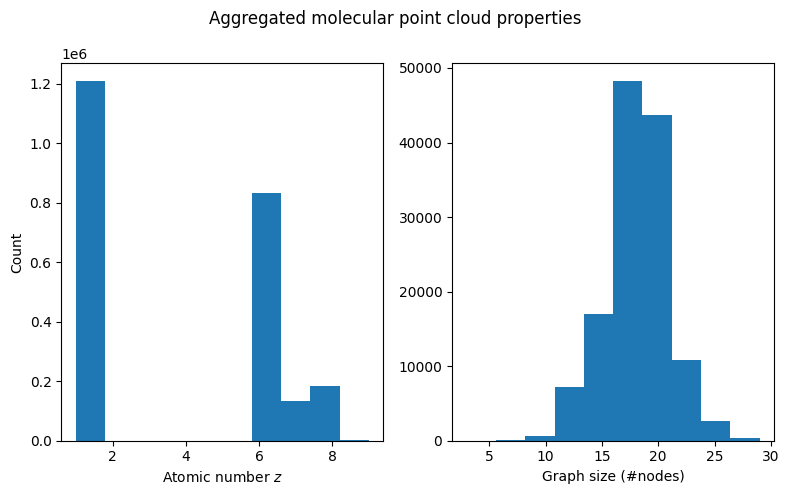

In [ ]:
fig, (ax_atoms, ax_graph_size) = plt.subplots(1, 2, figsize=(8, 5))

# ax_atoms.hist(dataset.data.z[dataset.data.z != 1])
ax_atoms.hist(dataset.data.z)
ax_atoms.set_xlabel("Atomic number $z$")
ax_atoms.set_ylabel("Count")
num_nodes = [dataset[i].num_nodes for i in range(len(dataset))]
ax_graph_size.hist(num_nodes)
ax_graph_size.set_xlabel("Graph size (#nodes)")
fig.suptitle("Aggregated molecular point cloud properties")
fig.tight_layout()

In [ ]:
class QM9DataModule:
    def __init__(
        self,
        train_ratio: float = 0.8,
        val_ratio: float = 0.1,
        test_ratio: float = 0.1,
        target_idx: int = 5,
        seed: float = 420,
    ) -> None:
        """Encapsulates everything related to the dataset

        Parameters
        ----------
        train_ratio : float, optional
            fraction of data used for training, by default 0.8
        val_ratio : float, optional
            fraction of data used for validation, by default 0.1
        test_ratio : float, optional
            fraction of data used for testing, by default 0.1
        target_idx : int, optional
            index of the target (see torch geometric docs), by default 5 (electronic spatial extent)
            (https://pytorch-geometric.readthedocs.io/en/latest/modules/datasets.html?highlight=qm9#torch_geometric.datasets.QM9)
        seed : float, optional
            random seed for data split, by default 420
        """
        assert sum([train_ratio, val_ratio, test_ratio]) == 1
        self.target_idx = target_idx
        self.num_examples = len(self.dataset())
        rng = np.random.default_rng(seed)
        self.shuffled_index = rng.permutation(self.num_examples)
        self.train_split = self.shuffled_index[: int(self.num_examples * train_ratio)]
        self.val_split = self.shuffled_index[
            int(self.num_examples * train_ratio) : int(
                self.num_examples * (train_ratio + val_ratio)
            )
        ]
        self.test_split = self.shuffled_index[
            int(self.num_examples * (train_ratio + val_ratio)) : self.num_examples
        ]

    def dataset(self, transform=None) -> QM9:
        dataset = QM9(
            DATA,
            pre_filter=lambda data: num_heavy_atoms(data) < 9,
            pre_transform=add_complete_graph_edge_index,
        )
        dataset.data.y = dataset.data.y[:, self.target_idx].view(-1, 1)
        return dataset

    def loader(self, split, **loader_kwargs) -> DataLoader:
        dataset = self.dataset()[split]
        return DataLoader(dataset, **loader_kwargs)

    def train_loader(self, **loader_kwargs) -> DataLoader:
        return self.loader(self.train_split, shuffle=True, **loader_kwargs)

    def val_loader(self, **loader_kwargs) -> DataLoader:
        return self.loader(self.val_split, shuffle=False, **loader_kwargs)

    def test_loader(self, **loader_kwargs) -> DataLoader:
        return self.loader(self.test_split, shuffle=False, **loader_kwargs)

In [ ]:
data_module = QM9DataModule()
dataset = data_module.dataset()
target = dataset.data.y.flatten().numpy()
print(target)

/usr/local/lib/python3.11/dist-packages/torch_geometric/data/dataset.py:249: UserWarning: The `pre_filter` argument differs from the one used in the pre-processed version of this dataset. If you want to make use of another pre-fitering technique, pass `force_reload=True` explicitly to reload the dataset.
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/torch_geometric/data/in_memory_dataset.py:300: UserWarning: It is not recommended to directly access the internal storage format `data` of an 'InMemoryDataset'. If you are absolutely certain what you are doing, access the internal storage via `InMemoryDataset._data` instead to suppress this warning. Alternatively, you can access stacked individual attributes of every graph via `dataset.{attr_name}`.
  warnings.warn(msg)


[ 35.3641  26.1563  19.0002 ... 780.3553 803.1904 756.3557]


In [ ]:
print(dataset.data.y)

tensor([[ 35.3641],
        [ 26.1563],
        [ 19.0002],
        ...,
        [780.3553],
        [803.1904],
        [756.3557]])


Text(0.5, 0.98, 'Random data split - target distribution')

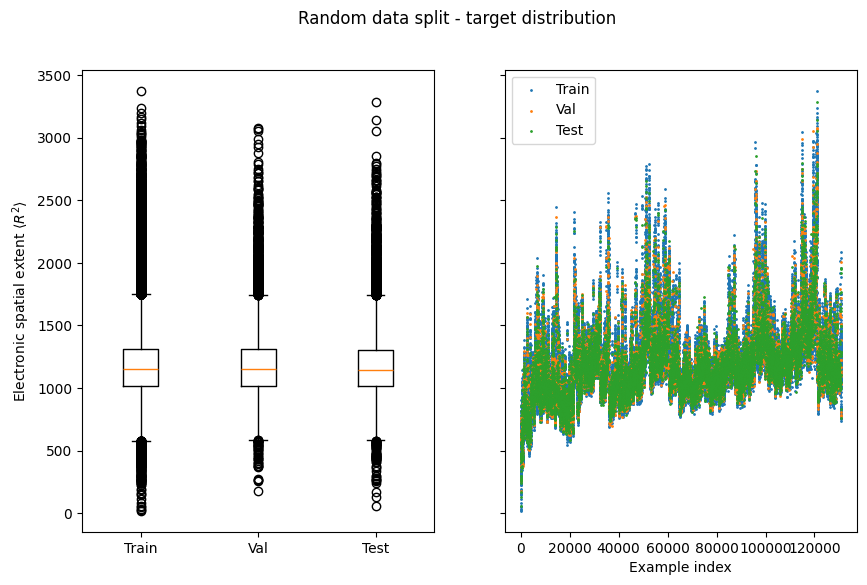

In [ ]:
# data_module = QM9DataModule()

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(10, 6), sharey=True)
target = data_module.dataset().data.y.flatten().numpy()
ax1.boxplot(
    [
        target[data_module.train_split],
        target[data_module.val_split],
        target[data_module.test_split],
    ]
)
ax1.set_xticklabels(["Train", "Val", "Test"])
ax1.set_ylabel("Electronic spatial extent $\langle R^2 \\rangle$")

for label, split in {
    "Train": data_module.train_split,
    "Val": data_module.val_split,
    "Test": data_module.test_split,
}.items():
    ax2.scatter(split, target[split], label=label, s=1)

ax2.set_xlabel("Example index")
ax2.legend()
fig.suptitle("Random data split - target distribution")

In [ ]:
class NaiveEuclideanGNN(nn.Module):
    def __init__(
        self,
        hidden_channels: int,
        num_layers: int,
        num_spatial_dims: int,
        final_embedding_size: Optional[int] = None,
        act: nn.Module = nn.ReLU(),
    ) -> None:
        super().__init__()
        # NOTE nn.Embedding acts like a lookup table.
        # Here we use it to store each atomic number in [0,100]
        # a learnable, fixed-size vector representation
        self.f_initial_embed = nn.Embedding(100, hidden_channels)
        self.f_pos_embed = nn.Linear(num_spatial_dims, hidden_channels)
        self.f_combine = nn.Sequential(nn.Linear(2 * hidden_channels, hidden_channels), act)

        if final_embedding_size is None:
            final_embedding_size = hidden_channels

        # Graph isomorphism network as main GNN
        # (see Talktorial 034)
        # takes care of message passing and
        # Learning node-level embeddings
        self.gnn = geom_nn.models.GIN(
            in_channels=hidden_channels,
            hidden_channels=hidden_channels,
            out_channels=final_embedding_size,
            num_layers=num_layers,
            act=act,
        )

        # modules required for aggregating node embeddings
        # into graph embeddings and making graph-level predictions
        self.aggregation = geom_nn.aggr.SumAggregation()
        self.f_predict = nn.Sequential(
            nn.Linear(final_embedding_size, final_embedding_size),
            act,
            nn.Linear(final_embedding_size, 1),
        )

    def encode(self, data: Data) -> Tensor:
        # initial atomic number embedding and embedding od positional information
        atom_embedding = self.f_initial_embed(data.z)
        pos_embedding = self.f_pos_embed(data.pos)

        # treat both as plain node-level features and combine into initial node-level
        # embedddings
        initial_node_embed = self.f_combine(torch.cat((atom_embedding, pos_embedding), dim=-1))

        # message passing
        # NOTE in contrast to the EGNN implemented later, this model does use bond information
        # i.e., data.egde_index stems from the bond adjacency matrix
        node_embed = self.gnn(initial_node_embed, data.edge_index)
        return node_embed

    def forward(self, data: Data) -> Tensor:
        node_embed = self.encode(data)
        aggr = self.aggregation(node_embed, data.batch)
        return self.f_predict(aggr)

In [ ]:
class EquivariantMPLayer(nn.Module):
    def __init__(
        self,
        in_channels: int,
        hidden_channels: int,
        act: nn.Module,
    ) -> None:
        super().__init__()
        self.act = act
        self.residual_proj = nn.Linear(in_channels, hidden_channels, bias=False)

        # Messages will consist of two (source and target) node embeddings and a scalar distance
        message_input_size = 2 * in_channels + 1

        # equation (3) "phi_l" NN
        self.message_mlp = nn.Sequential(
            nn.Linear(message_input_size, hidden_channels),
            act,
        )
        # equation (4) "psi_l" NN
        self.node_update_mlp = nn.Sequential(
            nn.Linear(in_channels + hidden_channels, hidden_channels),
            act,
        )

    def node_message_function(
        self,
        source_node_embed: Tensor,  # h_i
        target_node_embed: Tensor,  # h_j
        node_dist: Tensor,  # d_ij
    ) -> Tensor:
        # implements equation (3)
        message_repr = torch.cat((source_node_embed, target_node_embed, node_dist), dim=-1)
        return self.message_mlp(message_repr)

    def compute_distances(self, node_pos: Tensor, edge_index: LongTensor) -> Tensor:
        row, col = edge_index
        xi, xj = node_pos[row], node_pos[col]
        # relative squared distance
        # implements equation (2) ||X_i - X_j||^2
        rsdist = (xi - xj).pow(2).sum(1, keepdim=True)
        return rsdist

    def forward(
        self,
        node_embed: Tensor,
        node_pos: Tensor,
        edge_index: Tensor,
    ) -> Tensor:
        row, col = edge_index
        dist = self.compute_distances(node_pos, edge_index)

        # compute messages "m_ij" from  equation (3)
        node_messages = self.node_message_function(node_embed[row], node_embed[col], dist)

        # message sum aggregation in equation (4)
        aggr_node_messages = scatter(node_messages, col, dim=0, reduce="sum")

        # compute new node embeddings "h_i^{l+1}"
        # (implements rest of equation (4))
        new_node_embed = self.residual_proj(node_embed) + self.node_update_mlp(
            torch.cat((node_embed, aggr_node_messages), dim=-1)
        )

        return new_node_embed


class EquivariantGNN(nn.Module):
    def __init__(
        self,
        hidden_channels: int,
        final_embedding_size: Optional[int] = None,
        target_size: int = 1,
        num_mp_layers: int = 7,
    ) -> None:
        super().__init__()
        if final_embedding_size is None:
            final_embedding_size = hidden_channels

        # non-linear activation func.
        # usually configurable, here we just use Relu for simplicity
        self.act = nn.SiLU()

        # equation (1) "psi_0"
        self.f_initial_embed = nn.Embedding(100, hidden_channels)

        # create stack of message passing layers
        self.message_passing_layers = nn.ModuleList()
        channels = [hidden_channels] * (num_mp_layers) + [final_embedding_size]
        for d_in, d_out in zip(channels[:-1], channels[1:]):
            layer = EquivariantMPLayer(d_in, d_out, self.act)
            self.message_passing_layers.append(layer)

        # modules required for readout of a graph-level
        # representation and graph-level property prediction
        self.aggregation = SumAggregation()
        self.f_predict = nn.Sequential(
            nn.Linear(final_embedding_size, final_embedding_size),
            self.act,
            nn.Linear(final_embedding_size, target_size),
        )

    def encode(self, data: Data) -> Tensor:
        # theory, equation (1)
        node_embed = self.f_initial_embed(data.z)
        # print('f_initial_embed', node_embed.shape)
        # message passing
        # theory, equation (3-4)
        for mp_layer in self.message_passing_layers:
            # NOTE here we use the complete edge index defined by the transform earlier on
            # to implement the sum over $j \neq i$ in equation (4)
            node_embed = mp_layer(node_embed, data.pos, data.complete_edge_index)
        # print('message passing layers', node_embed.shape)
        return node_embed

    def _predict(self, node_embed, batch_index) -> Tensor:
        aggr = self.aggregation(node_embed, batch_index)
        # return aggr
        return self.f_predict(aggr)

    def forward(self, data: Data) -> Tensor:
        node_embed = self.encode(data)
        # print(node_embed.shape)
        pred = self._predict(node_embed, data.batch)
        return pred

In [ ]:
# We will be using mean absolute error
# as a metric for validation and testing
def total_absolute_error(pred: Tensor, target: Tensor, batch_dim: int = 0) -> Tensor:
    """Total absolute error, i.e. sums over batch dimension.

    Parameters
    ----------
    pred : Tensor
        batch of model predictions
    target : Tensor
        batch of ground truth / target values
    batch_dim : int, optional
        dimension that indexes batch elements, by default 0

    Returns
    -------
    Tensor
        total absolute error
    """
    return (pred - target).abs().sum(batch_dim)

In [ ]:
batch_size=32
train_loader = data_module.train_loader(batch_size=batch_size)
val_loader = data_module.val_loader(batch_size=batch_size)

/usr/local/lib/python3.11/dist-packages/torch_geometric/data/dataset.py:249: UserWarning: The `pre_filter` argument differs from the one used in the pre-processed version of this dataset. If you want to make use of another pre-fitering technique, pass `force_reload=True` explicitly to reload the dataset.
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/torch_geometric/data/in_memory_dataset.py:300: UserWarning: It is not recommended to directly access the internal storage format `data` of an 'InMemoryDataset'. If you are absolutely certain what you are doing, access the internal storage via `InMemoryDataset._data` instead to suppress this warning. Alternatively, you can access stacked individual attributes of every graph via `dataset.{attr_name}`.
  warnings.warn(msg)


In [ ]:
import time

In [ ]:
def run_epoch(
    model: nn.Module,
    loader: DataLoader,
    criterion: Callable[[Tensor, Tensor], Tensor],
    pbar: Optional[Any] = None,
    optim: Optional[torch.optim.Optimizer] = None,
):
    """Run a single epoch.

    Parameters
    ----------
    model : nn.Module
        the NN used for regression
    loader : DataLoader
        an iterable over data batches
    criterion : Callable[[Tensor, Tensor], Tensor]
        a criterion (loss) that is optimized
    pbar : Optional[Any], optional
        a tqdm progress bar, by default None
    optim : Optional[torch.optim.Optimizer], optional
        a optimizer that is optimizing the criterion, by default None
    """

    def step(
        data_batch: Data,
    ) -> Tuple[float, float]:
        """Perform a single train/val step on a data batch.

        Parameters
        ----------
        data_batch : Data

        Returns
        -------
        Tuple[float, float]
            Loss (mean squared error) and validation critierion (absolute error).
        """
        pred = model.forward(data_batch)
        target = data_batch.y
        loss = criterion(pred, target)
        if optim is not None:
            optim.zero_grad()
            loss.backward()
            optim.step()
        return loss.detach().item(), total_absolute_error(pred.detach(), target.detach())

    if optim is not None:
        model.train()
        # This enables pytorch autodiff s.t. we can compute gradients
        model.requires_grad_(True)
    else:
        model.eval()
        # disable autodiff: when evaluating we do not need to track gradients
        model.requires_grad_(False)

    total_loss = 0
    total_mae = 0
    for data in loader:
        data = data.to(device)
        loss, mae = step(data)
        total_loss += loss * data.num_graphs
        total_mae += mae
        if pbar is not None:
            pbar.update(1)

    return total_loss / len(loader.dataset), total_mae / len(loader.dataset)


def train_model(
    data_module: QM9DataModule,
    model: nn.Module,
    num_epochs: int = 30,
    lr: float = 3e-4,
    batch_size: int = 32,
    weight_decay: float = 1e-8,
    best_model_path: Path = DATA.joinpath("trained_model.pth"),
) -> Dict[str, Any]:
    """Takes data and model as input and runs training, collecting additional validation metrics
    while doing so.

    Parameters
    ----------
    data_module : QM9DataModule
        a data module as defined earlier
    model : nn.Module
        a gnn model
    num_epochs : int, optional
        number of epochs to train for, by default 30
    lr : float, optional
        "learning rate": optimizer SGD step size, by default 3e-4
    batch_size : int, optional
        number of examples used for one training step, by default 32
    weight_decay : float, optional
        L2 regularization parameter, by default 1e-8
    best_model_path : Path, optional
        path where the model weights with lowest val. error should be stored
        , by default DATA.joinpath("trained_model.pth")

    Returns
    -------
    Dict[str, Any]
        a training result, ie statistics and info about the model
    """
    # create data loaders
    train_loader = data_module.train_loader(batch_size=batch_size)
    val_loader = data_module.val_loader(batch_size=batch_size)

    # setup optimizer and loss
    optim = torch.optim.Adam(model.parameters(), lr, weight_decay=1e-8)
    loss_fn = nn.MSELoss()

    # keep track of the epoch with the best validation mae
    # st we can save the "best" model weights
    best_val_mae = float("inf")

    # Statistics that will be plotted later on
    # and model info
    result = {
        "model": model,
        "path_to_best_model": best_model_path,
        "train_loss": np.full(num_epochs, float("nan")),
        "val_loss": np.full(num_epochs, float("nan")),
        "train_mae": np.full(num_epochs, float("nan")),
        "val_mae": np.full(num_epochs, float("nan")),
    }

    # Auxiliary functions for updating and reporting
    # Training progress statistics
    def update_statistics(i_epoch: int, **kwargs: float):
        for key, value in kwargs.items():
            result[key][i_epoch] = value

    def desc(i_epoch: int) -> str:
        return " | ".join(
            [f"Epoch {i_epoch + 1:3d} / {num_epochs}"]
            + [
                f"{key}: {value[i_epoch]:8.2f}"
                for key, value in result.items()
                if isinstance(value, np.ndarray)
            ]
        )

    # main training loop
    for i_epoch in range(0, num_epochs):
        progress_bar = tqdm(total=len(train_loader) + len(val_loader))
        try:
            # tqdm for reporting progress
            progress_bar.set_description(desc(i_epoch))

            # training epoch
            train_loss, train_mae = run_epoch(model, train_loader, loss_fn, progress_bar, optim)
            # validation epoch
            val_loss, val_mae = run_epoch(model, val_loader, loss_fn, progress_bar)

            update_statistics(
                i_epoch,
                train_loss=train_loss,
                val_loss=val_loss,
                train_mae=train_mae,
                val_mae=val_mae,
            )

            progress_bar.set_description(desc(i_epoch))

            if val_mae < best_val_mae:
                best_val_mae = val_mae
                torch.save(model.state_dict(), best_model_path)
        finally:
            progress_bar.close()

    return result

In [ ]:
import torch
import numpy as np
from torch import nn, Tensor
from typing import Tuple
from pathlib import Path


@torch.no_grad()
def evaluate_split(model: nn.Module, loader, split_name: str) -> Tuple[Tensor, Tensor]:
    preds, targets = [], []
    for data in loader:
        pred = model(data)
        preds.append(pred)
        targets.append(data.y)
    preds = torch.cat(preds, dim=0)
    targets = torch.cat(targets, dim=0)
    return preds, targets


@torch.no_grad()
def test_model(model: nn.Module, data_module, save_path: str = "predictions_and_targets.npz") -> Tuple[float, Tensor, Tensor]:
    """
    Test a model and save predictions and targets.

    Parameters
    ----------
    model : nn.Module
        A trained model.
    data_module : QM9DataModule
        The data module.
    save_path : str
        Path to save the npz file.

    Returns
    -------
    Tuple[float, Tensor, Tensor]
        Test MAE, test predictions, test targets.
    """
    model.eval()

    # Evaluate all splits
    pred_train, target_train = evaluate_split(model, data_module.train_loader(), "train")
    pred_val, target_val = evaluate_split(model, data_module.val_loader(), "val")
    pred_test, target_test = evaluate_split(model, data_module.test_loader(), "test")

    # Compute test MAE
    test_mae = torch.mean(torch.abs(pred_test - target_test)).item()

    # Save all data in npz format
    np.savez(
        save_path,
        pred_train=pred_train.cpu().numpy(),
        target_train=target_train.cpu().numpy(),
        pred_val=pred_val.cpu().numpy(),
        target_val=target_val.cpu().numpy(),
        pred_test=pred_test.cpu().numpy(),
        target_test=target_test.cpu().numpy(),
    )

    return test_mae, pred_test, target_test


In [ ]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

In [ ]:
model = EquivariantGNN(hidden_channels=64, num_mp_layers=3).to(device)

egnn_train_result = train_model(
    data_module,
    model,
    num_epochs=25,
    lr=2e-4,
    batch_size=32,
    weight_decay=1e-8,
    best_model_path=DATA.joinpath("trained_egnn.pth"),
)

Epoch   1 / 25 | train_loss: 14048.30 | val_loss:   599.63 | train_mae:    42.95 | val_mae:    19.23: 100%|██████████| 3680/3680 [01:02<00:00, 58.47it/s]
Epoch   2 / 25 | train_loss:   290.77 | val_loss:   879.55 | train_mae:    12.47 | val_mae:    23.71: 100%|██████████| 3680/3680 [00:39<00:00, 94.13it/s] 
Epoch   3 / 25 | train_loss:   181.27 | val_loss:    51.17 | train_mae:     9.55 | val_mae:     4.86: 100%|██████████| 3680/3680 [00:39<00:00, 93.86it/s] 
Epoch   4 / 25 | train_loss:   117.79 | val_loss:    75.68 | train_mae:     7.81 | val_mae:     6.18: 100%|██████████| 3680/3680 [00:39<00:00, 93.93it/s] 
Epoch   5 / 25 | train_loss:   105.34 | val_loss:    31.59 | train_mae:     7.35 | val_mae:     3.94: 100%|██████████| 3680/3680 [00:38<00:00, 95.49it/s] 
Epoch   6 / 25 | train_loss:    76.08 | val_loss:    22.89 | train_mae:     6.30 | val_mae:     3.49: 100%|██████████| 3680/3680 [00:38<00:00, 95.10it/s] 
Epoch   7 / 25 | train_loss:    69.92 | val_loss:    15.57 | train_mae:

In [ ]:
model = model.to('cpu')
egnn_test_mae, egnn_preds, egnn_targets = test_model(model, data_module)

print(f"EGNN test MAE: {egnn_test_mae}")

EGNN test MAE: 3.2323296070098877


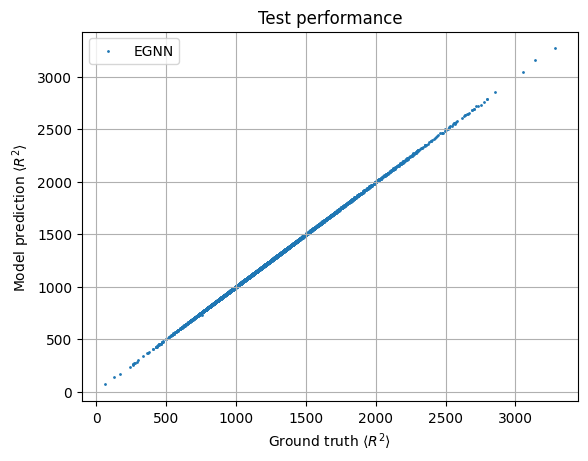

In [ ]:
fig, ax = plt.subplots()
ax.scatter(egnn_targets, egnn_preds, s=1, label="EGNN")
ax.set_ylabel("Model prediction $\langle R^2 \\rangle$")
ax.set_xlabel("Ground truth $\langle R^2 \\rangle$")
ax.set_title("Test performance")
plt.grid()
ax.legend()